# Scoring cuantitativo de fondos mutuos USA

**Prueba tecnica — Analista de Renta Variable Internacional, AFP Habitat**

*David Gonzalez — FEN, Universidad de Chile*

---

**Objetivo:** construir un sistema cuantitativo que asigne un puntaje a cada fondo
del universo para informar la decision de inversion, distinguiendo fondos atractivos
de poco atractivos.

**Target elegido:** percentil cross-seccional del **Sortino ratio forward a 6 meses**
(`target_sortino_rank_6m`). El Sortino penaliza solo volatilidad a la baja — la
volatilidad al alza es deseable para un fondo de pension, no penalizable.

**Filosofia:** modelo explicativo con validacion predictiva. ElasticNet como
primario (coeficientes interpretables, defendibles ante comite) + LightGBM como
sanity check no-lineal.

### Enfoque predictivo vs explicativo

La tension entre modelos predictivos y explicativos es central en finanzas
aplicadas. Para una AFP, ambas dimensiones son requisito:

- **Dimension explicativa.** Una AFP debe justificar ante su comite de
  inversiones y ante la regulacion *por que* selecciono ciertos fondos.
  "El modelo dijo" no basta — hay que poder argumentar: "el modelo
  penaliza fee alto y premia consistencia de retorno ajustada por riesgo
  bajista, que son principios de inversion solidos." Los coeficientes del
  ElasticNet son directamente interpretables: cada uno mide cuanto cambia
  el score al mover una feature un desvio estandar.

- **Dimension predictiva.** Sin validacion fuera de muestra estricta
  (walk-forward, embargo, bootstrap CI), un modelo explicativo puede ser
  una racionalizacion post-hoc: coeficientes que "hacen sentido" pero no
  generalizan a datos futuros. La validacion predictiva es el antidoto
  contra el sobreajuste narrativo.

- **Trade-off.** Un modelo mas complejo (deep learning, ensemble de
  gradient boosting) podria mejorar el IC en 1-2 bps marginales, pero
  perderia interpretabilidad — inaceptable para gobernanza de inversiones.
  El ElasticNet representa el punto optimo: suficientemente flexible para
  capturar senales lineales con regularizacion, suficientemente simple
  para que cada prediccion sea auditable.

**Reproducibilidad:**
```bash
pip install -r requirements.txt         # instalar dependencias
python -m scripts.run_all               # pipeline completo (requiere assets/usa_fondos_pp.sqlite)
jupyter notebook notebooks/informe.ipynb
```

*Nota: la primera celda de codigo instala automaticamente las dependencias
necesarias para ejecutar este notebook. No se requiere `uv` ni ningun
package manager especifico — basta con Python >=3.12.*

In [1]:
# --- Instalacion automatica de dependencias ---
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "pandas>=2.0", "numpy>=1.26", "matplotlib>=3.8",
    "seaborn>=0.13", "pyarrow>=14",
])

0

In [2]:
import json
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130,
                      "axes.spines.top": False, "axes.spines.right": False})

# Rutas del proyecto
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "assets" / "usa_fondos_pp.sqlite"
ARTIFACTS = ROOT / "artifacts"
APP_DATA = ROOT / "app" / "backend" / "data"

# Para importar src/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Raiz del proyecto: {ROOT}")
print(f"Base de datos: {DB_PATH} (existe: {DB_PATH.exists()})")

Raiz del proyecto: C:\Users\dgonz\PycharmProjects\Blooomberg
Base de datos: C:\Users\dgonz\PycharmProjects\Blooomberg\assets\usa_fondos_pp.sqlite (existe: True)


### Estructura del notebook

Este notebook es un **informe para el evaluador** — muestra versiones
simplificadas de las transformaciones clave para que se pueda seguir el
razonamiento paso a paso. El pipeline de produccion (modular, reutilizable)
vive en `src/` y se ejecuta via `scripts/01..05`:

```
01_build_features     → panel_raw.parquet    (datos diarios → panel mensual)
02_eda_report         → plots/               (graficos exploratorios)
03_build_features_full→ panel_features.parquet(32 features + targets)
04_train_and_evaluate → scores, metrics      (walk-forward, modelos, CI)
05_build_app_data     → app/backend/data/    (JSONs para el dashboard)
```

Las secciones que involucran carga de datos y construccion de features
reproducen el codigo inline con fines didacticos. Las secciones pesadas
(entrenamiento, walk-forward, metricas de evaluacion) **no se re-ejecutan**:
el notebook carga los artefactos pre-computados (`scores.parquet`,
`metrics.json`, etc.) y los presenta con visualizaciones y narrativa.

En cada seccion se incluyen comentarios que referencian el modulo `src/`
correspondiente, para que quien revise pueda navegar al codigo de produccion.

---
## 1. Carga de datos desde SQL

El dataset vive en una base SQLite (`assets/usa_fondos_pp.sqlite`, ~80 MB,
no versionada en git). Contiene tres tablas:

| Tabla | Contenido |
|---|---|
| `historico` | Precio diario (NAV) y eventos de capital por fondo |
| `fees` | Fee anual reportado (solo desde 2024-01-31) |
| `subyacentes` | Concentracion del portafolio (n_instrumentos, pct_acum) |

In [3]:
# --- Tabla 1: historico ---
# En el pipeline, la carga y limpieza la hace src/data.py → load_historico()
con = sqlite3.connect(DB_PATH)

historico = pd.read_sql(
    "SELECT fecha, securities AS fondo, precio, evento_pct FROM historico",
    con, parse_dates=["fecha"]
)
historico = historico.dropna(subset=["precio"]).sort_values(["fondo", "fecha"]).reset_index(drop=True)

print(f"historico: {historico.shape[0]:,} filas x {historico.shape[1]} columnas")
print(f"Fondos: {historico['fondo'].nunique()}")
print(f"Rango: {historico['fecha'].min().date()} -> {historico['fecha'].max().date()}")
historico.head(8)

historico: 1,201,276 filas x 4 columnas
Fondos: 277
Rango: 1988-11-17 -> 2026-05-01


,fecha,fondo,precio,evento_pct
0,2005-10-03,FONDO_0001,43.15,0.0
1,2005-10-04,FONDO_0001,43.35,0.0
2,2005-10-05,FONDO_0001,43.27,0.0
3,2005-10-06,FONDO_0001,42.68,0.0
4,2005-10-07,FONDO_0001,42.05,0.0
5,2005-10-10,FONDO_0001,42.07,0.0
6,2005-10-11,FONDO_0001,41.77,0.0
7,2005-10-12,FONDO_0001,41.67,0.0


In [4]:
# --- Tabla 2: fees ---
fees = pd.read_sql("SELECT fecha, fondo, fee FROM fees", con, parse_dates=["fecha"])
fees = fees.dropna(subset=["fee"]).query("fee > 0")

print(f"fees: {fees.shape[0]:,} filas")
print(f"Fondos con fee reportado: {fees['fondo'].nunique()}")
print(f"Rango: {fees['fecha'].min().date()} -> {fees['fecha'].max().date()}")
fees.describe()

fees: 66,491 filas
Fondos con fee reportado: 274
Rango: 2024-01-01 -> 2026-04-09


,fecha,fee
count,66491,66491.000000
mean,2025-01-08 16:22:54.357432,0.321389
min,2024-01-01 00:00:00,0.020000
25%,2024-09-02 00:00:00,0.080000
50%,2025-01-01 00:00:00,0.250000
75%,2025-05-01 00:00:00,0.390000
max,2026-04-09 00:00:00,3.000000
std,NaN,0.348581


In [5]:
# --- Tabla 3: subyacentes ---
subyacentes = pd.read_sql(
    "SELECT fecha, nemo_fondo AS fondo, pct_acum, n_instrumentos FROM subyacentes",
    con, parse_dates=["fecha"]
)
con.close()

print(f"subyacentes: {subyacentes.shape[0]:,} filas")
print(f"Fondos: {subyacentes['fondo'].nunique()}")
subyacentes.describe()

subyacentes: 129 filas
Fondos: 129


,fecha,pct_acum,n_instrumentos
count,129,129.000000,129.000000
mean,2023-06-24 11:09:46.046511,0.318045,23.775194
min,2012-04-30 00:00:00,0.300014,2.000000
25%,2023-04-26 00:00:00,0.303365,5.000000
50%,2025-10-28 00:00:00,0.308040,9.000000
75%,2025-10-28 00:00:00,0.321188,21.000000
max,2026-03-13 00:00:00,0.423616,161.000000
std,NaN,0.024811,34.477629


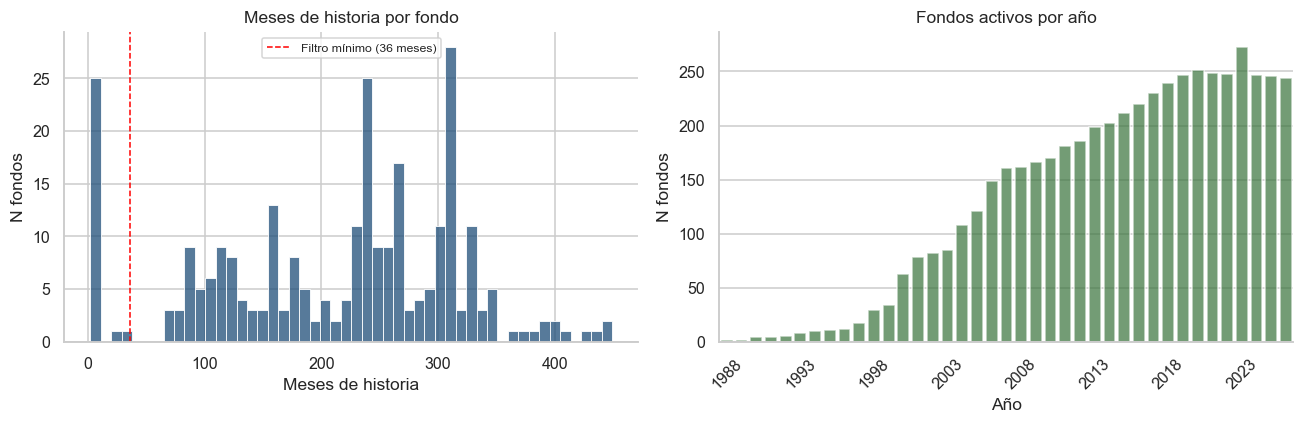

In [6]:
# Distribucion de meses de historia por fondo — informa sobre la profundidad
# del universo y anticipa el filtro de >=36 meses que se aplica mas adelante
meses_por_fondo = historico.groupby("fondo")["fecha"].apply(
    lambda s: (s.max() - s.min()).days / 30.44
).rename("meses_hist")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(meses_por_fondo, bins=50, ax=axes[0], color="#1f4e79")
axes[0].set_title("Meses de historia por fondo")
axes[0].set_xlabel("Meses de historia")
axes[0].set_ylabel("N fondos")
axes[0].axvline(36, color="red", ls="--", lw=1, label="Filtro mínimo (36 meses)")
axes[0].legend(fontsize=8)

# Fondos activos por año
fondos_por_anio = (
    historico.assign(anio=historico["fecha"].dt.year)
    .groupby("anio")["fondo"].nunique()
)
sns.barplot(x=fondos_por_anio.index, y=fondos_por_anio.values, ax=axes[1], color="#2e7d32", alpha=0.7)
axes[1].set_title("Fondos activos por año")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("N fondos")
axes[1].tick_params(axis="x", rotation=45)
# Mostrar solo cada 5 años
ticks = axes[1].get_xticks()
axes[1].set_xticks(ticks[::5])

fig.tight_layout()

**Observaciones:**
- 277 fondos en total, con entradas distribuidas desde 1988.
- La mayoria de los fondos tiene entre 100 y 400 meses de historia. La linea
  roja marca el filtro minimo de 36 meses que se aplica en el modelado.
- El universo activo crece fuertemente a partir de ~2000 y se estabiliza ~2010.

---
## 2. Retorno total y panel mensual

El retorno total que recibe el inversionista combina dos componentes:

$$r^{total}_t = \frac{P_t}{P_{t-1}} - 1 + \text{evento\_pct}_t$$

Donde `evento_pct` captura distribuciones de capital (dividendos, capital gains).
Sin este componente, se subestima el retorno en fondos con distribuciones recurrentes.

In [7]:
# Paso 1: retorno por variacion de precio (NAV day-over-day)
# En el pipeline, este calculo lo hace src/data.py → compute_daily_total_return()
historico = historico.sort_values(["fondo", "fecha"]).reset_index(drop=True)
historico["ret_precio"] = historico.groupby("fondo")["precio"].pct_change()

# Paso 2: retorno total crudo = variacion de precio + evento de capital
historico["ret_total_raw"] = historico["ret_precio"].fillna(0) + historico["evento_pct"].fillna(0)

# Paso 3: winsorizacion del retorno total al p99.5
# Se winsoriza el retorno TOTAL (no solo el evento) porque en eventos de
# split/reverse-split el precio cae y el evento compensa — winsorizar solo
# el evento destruye la cancelacion natural y genera drawdowns ficticios
cap = historico["ret_total_raw"].replace(0, np.nan).abs().quantile(0.995)
historico["ret_total"] = historico["ret_total_raw"].clip(lower=-cap, upper=cap)
print(f"Cap de winsorizacion: +/-{cap:.4f} ({cap*100:.2f}%)")

# La primera observacion de cada fondo no tiene retorno calculable
historico.loc[historico.groupby("fondo").head(1).index, "ret_total"] = np.nan

Cap de winsorizacion: +/-0.0625 (6.25%)


In [8]:
# Paso 4: Total Return Index (TRI) — normalizado a 1.0 en la primera obs
historico["one_plus_r"] = 1 + historico["ret_total"].fillna(0)
historico["tri"] = historico.groupby("fondo")["one_plus_r"].cumprod()

# Paso 5: agregacion a mensual — ultimo TRI del mes
historico["mes"] = historico["fecha"].dt.to_period("M").dt.to_timestamp("M")
eom = (
    historico.sort_values("fecha")
    .groupby(["fondo", "mes"])
    .tail(1)[["fondo", "mes", "tri"]]
    .rename(columns={"tri": "tri_eom"})
)
# Retorno mensual = variacion del TRI entre cierres de mes consecutivos
eom["ret_mensual"] = eom.groupby("fondo")["tri_eom"].pct_change()

print(f"Panel mensual: {eom.shape[0]:,} observaciones fondo-mes")
print(f"Fondos: {eom['fondo'].nunique()}, Meses: {eom['mes'].nunique()}")

Panel mensual: 58,396 observaciones fondo-mes
Fondos: 277, Meses: 451


### Features intra-mes: microestructura desde datos diarios

Las features a nivel mensual (ret_1m, vol_12m, etc.) pierden informacion
sobre **como se distribuye el retorno dentro del mes**. Las features
intra-mes capturan propiedades de microestructura que solo son observables
en datos diarios:

- **`vol_intrames`**: volatilidad diaria dentro del mes — captura regimenes
  de alta incertidumbre (e.g., meses con un solo dia de crash y recuperacion).
- **`autocorr_diaria`**: autocorrelacion de lag-1 del retorno diario.
  Valores altos sugieren pricing stale o subyacentes iliquidos.
- **`ratio_dias_cero`**: fraccion de dias sin movimiento de precio.
  Proxy de iliquidez del fondo o de sus activos subyacentes.
- **`evento_pct_mes`**: suma de eventos de capital en el mes (dividendos,
  capital gains). Permite distinguir fondos de acumulacion vs distribucion.

In [9]:
# Paso 6: features intra-mes (calculadas desde datos diarios)
daily = historico.dropna(subset=["ret_total"]).copy()
daily["mes_agg"] = daily["fecha"].dt.to_period("M").dt.to_timestamp("M")

def _agg_intrames(g):
    """Features intra-mes por fondo-mes."""
    r = g["ret_total"]
    n = len(r)
    return pd.Series({
        "vol_intrames": r.std() if n >= 2 else np.nan,
        "autocorr_diaria": r.autocorr(lag=1) if n >= 5 else np.nan,
        "ratio_dias_cero": (r.abs() < 0.0001).mean(),
        "evento_pct_mes": g["evento_pct"].fillna(0).sum(),
    })

intra = daily.groupby(["fondo", "mes_agg"]).apply(_agg_intrames, include_groups=False).reset_index()
intra = intra.rename(columns={"mes_agg": "mes"})

# Merge al panel mensual
panel_raw = eom.merge(intra, on=["fondo", "mes"], how="left")
panel_raw = panel_raw.sort_values(["fondo", "mes"]).reset_index(drop=True)

print(f"panel_raw: {panel_raw.shape[0]:,} filas x {panel_raw.shape[1]} columnas")
panel_raw.head(10)

panel_raw: 58,396 filas x 8 columnas


,fondo,mes,tri_eom,ret_mensual,vol_intrames,autocorr_diaria,ratio_dias_cero,evento_pct_mes
0,FONDO_0001,2005-10-31,0.937249,NaN,0.018181,-0.345444,0.000000,0.000000
1,FONDO_0001,2005-11-30,0.972195,0.037286,0.006351,-0.088984,0.000000,0.000000
2,FONDO_0001,2005-12-31,0.962999,-0.009459,0.008195,-0.568122,0.142857,0.000000
3,FONDO_0001,2006-01-31,0.945131,-0.018554,0.007259,-0.140589,0.136364,0.000000
4,FONDO_0001,2006-02-28,0.978501,0.035307,0.010181,-0.557206,0.100000,0.000000
5,FONDO_0001,2006-03-31,0.960897,-0.017991,0.005362,-0.164498,0.043478,0.000000
6,FONDO_0001,2006-04-30,0.935350,-0.026587,0.005539,-0.476828,0.000000,0.008297
7,FONDO_0001,2006-05-31,0.916272,-0.020397,0.007806,-0.176999,0.090909,0.000000
8,FONDO_0001,2006-06-30,0.927401,0.012146,0.007634,-0.243491,0.045455,0.000000
9,FONDO_0001,2006-07-31,0.958231,0.033244,0.007373,-0.328975,0.047619,0.010163


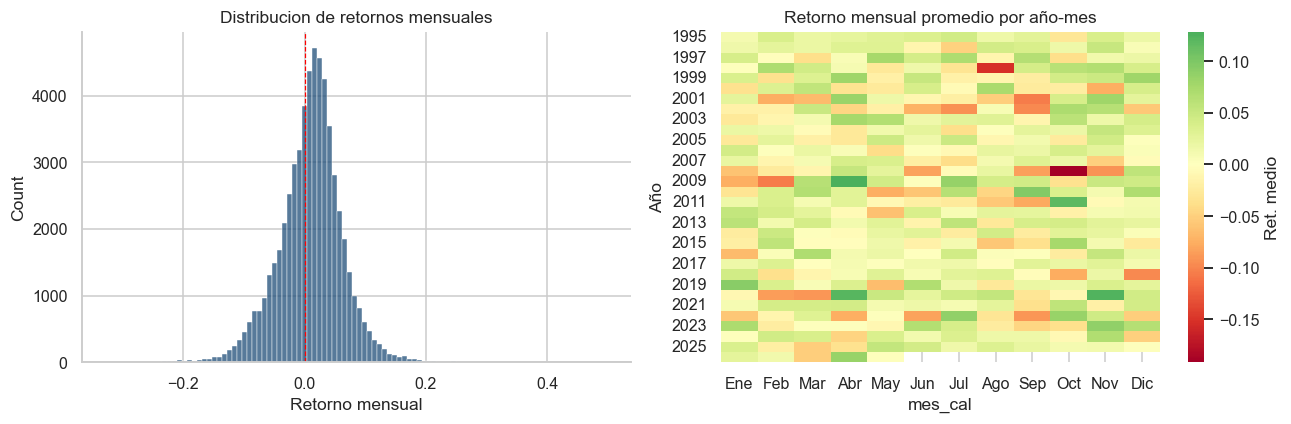

In [10]:
# Distribucion de retornos mensuales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(panel_raw["ret_mensual"].dropna(), bins=100, ax=axes[0], color="#1f4e79")
axes[0].set_title("Distribucion de retornos mensuales")
axes[0].set_xlabel("Retorno mensual")
axes[0].axvline(0, color="red", ls="--", lw=0.8)

# Heatmap de retorno promedio por año y mes calendario
panel_raw["anio"] = panel_raw["mes"].dt.year
panel_raw["mes_cal"] = panel_raw["mes"].dt.month
ret_heatmap = panel_raw.pivot_table(
    values="ret_mensual", index="anio", columns="mes_cal", aggfunc="mean"
)
# Filtrar años con suficientes datos
ret_heatmap = ret_heatmap.loc[ret_heatmap.index >= 1995]
sns.heatmap(ret_heatmap, cmap="RdYlGn", center=0, ax=axes[1],
            xticklabels=["Ene","Feb","Mar","Abr","May","Jun",
                         "Jul","Ago","Sep","Oct","Nov","Dic"],
            cbar_kws={"label": "Ret. medio"})
axes[1].set_title("Retorno mensual promedio por año-mes")
axes[1].set_ylabel("Año")

# Limpiar columnas auxiliares
panel_raw = panel_raw.drop(columns=["anio", "mes_cal"])
fig.tight_layout()

**Observaciones:**
- La distribucion de retornos mensuales es aproximadamente simetrica alrededor de 0,
  con colas moderadas. La mediana es ligeramente positiva (~0.5-1% mensual).
- El heatmap muestra la crisis de 2008-2009 (rojos intensos) y periodos de
  bull market (2013, 2019, 2021).
- Las features intra-mes (`vol_intrames`, `autocorr_diaria`, `ratio_dias_cero`)
  capturan propiedades de microestructura que se pierden al agregar a mensual.

---
## 3. Imputacion de fees y concentracion

### Fee: solo reporta desde 2024, pero es estructural

El dataset reporta fees a partir de 2024-01-31 — el **89% del panel es NaN**.
Sin embargo, el fee de un mutual fund USA es estructuralmente estable:
la desviacion intra-fondo es $\approx 0$.

Estadisticas del fee intra-fondo:
  Mediana de std intra-fondo: 0.000000
  % fondos con std = 0: 74.1%
  Fondos con fee reportado: 274

Cobertura fee:
  Antes:  11.6%
  Despues: 97.8%


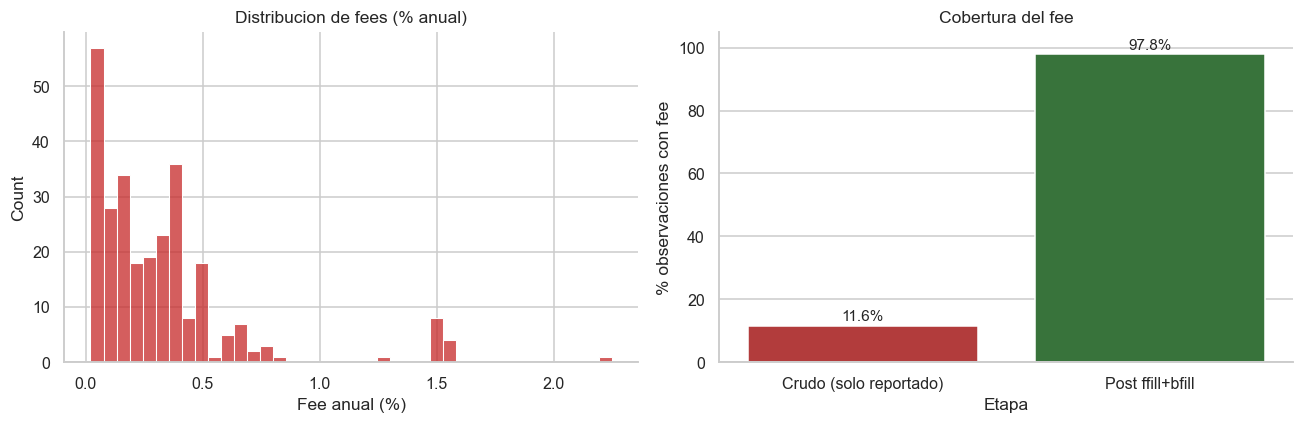

In [11]:
# Verificacion empirica: variabilidad del fee dentro de cada fondo
# En el pipeline, la imputacion la hace src/data.py → attach_fees()
fee_por_fondo = (
    fees.groupby("fondo")["fee"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n_obs", "mean": "fee_medio", "std": "fee_std"})
)
fee_por_fondo["fee_std"] = fee_por_fondo["fee_std"].fillna(0)

print("Estadisticas del fee intra-fondo:")
print(f"  Mediana de std intra-fondo: {fee_por_fondo['fee_std'].median():.6f}")
print(f"  % fondos con std = 0: {(fee_por_fondo['fee_std'] == 0).mean():.1%}")
print(f"  Fondos con fee reportado: {len(fee_por_fondo)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(fee_por_fondo["fee_medio"], bins=40, ax=axes[0], color="#c62828")
axes[0].set_title("Distribucion de fees (% anual)")
axes[0].set_xlabel("Fee anual (%)")

# Cobertura del fee antes y despues de imputacion
# Adjuntar fees al panel con ffill+bfill
fees_sorted = fees.sort_values(["fondo", "fecha"])
fees_eom = (
    fees_sorted.assign(mes=lambda x: x["fecha"].dt.to_period("M").dt.to_timestamp("M"))
    .groupby(["fondo", "mes"]).tail(1)[["fondo", "mes", "fee"]]
)
panel_fee = panel_raw[["fondo", "mes"]].merge(fees_eom, on=["fondo", "mes"], how="left")

cobertura_antes = panel_fee["fee"].notna().mean()
panel_fee["fee_observado"] = panel_fee["fee"].notna().astype(int)
panel_fee["fee"] = panel_fee.groupby("fondo")["fee"].transform(lambda s: s.ffill().bfill())
cobertura_despues = panel_fee["fee"].notna().mean()

bardata = pd.DataFrame({
    "Etapa": ["Crudo (solo reportado)", "Post ffill+bfill"],
    "Cobertura": [cobertura_antes * 100, cobertura_despues * 100]
})
sns.barplot(data=bardata, x="Etapa", y="Cobertura", ax=axes[1],
            palette=["#c62828", "#2e7d32"])
axes[1].set_title("Cobertura del fee")
axes[1].set_ylabel("% observaciones con fee")
axes[1].set_ylim(0, 105)
for i, v in enumerate(bardata["Cobertura"]):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10)

fig.tight_layout()

print(f"\nCobertura fee:")
print(f"  Antes:  {cobertura_antes:.1%}")
print(f"  Despues: {cobertura_despues:.1%}")

**Decision documentada:** dado que la std intra-fondo es $\approx 0$, el fee es
efectivamente constante en el tiempo para cada fondo. Aplicar `ffill+bfill` dentro
de cada fondo propaga el valor reportado en 2024+ hacia atras, llevando la
cobertura de ~11% a ~98%. La flag `fee_observado` (1 = dato original, 0 = imputado)
permite al modelo distinguir ambos casos.

### Concentracion: n_instrumentos via forward-fill

`n_instrumentos` = minimo de holdings para acumular 30% del AUM (snapshot del portafolio).
Solo se aplica `ffill` (no `bfill`) porque la composicion SI varia en el tiempo.

In [12]:
# Cobertura de concentracion
n_fondos_con_sub = subyacentes["fondo"].nunique()
n_fondos_total = historico["fondo"].nunique()
print(f"Fondos con datos de concentracion: {n_fondos_con_sub} de {n_fondos_total} "
      f"({n_fondos_con_sub/n_fondos_total:.0%})")
print(f"pct_acum: min={subyacentes['pct_acum'].min():.3f}, "
      f"max={subyacentes['pct_acum'].max():.3f}, "
      f"mediana={subyacentes['pct_acum'].median():.3f}")

Fondos con datos de concentracion: 129 de 277 (47%)
pct_acum: min=0.300, max=0.424, mediana=0.308


---
## 4. Feature engineering — 32 features

Todas las features son estrictamente **backward-looking** — usan solo
informacion disponible hasta la fecha de observacion. El unico elemento
forward-looking es el **target** (Sortino forward 6m), protegido por un
embargo igual al horizonte en el esquema walk-forward. Esta disciplina
anti-leakage (Lopez de Prado, *Advances in Financial Machine Learning*)
es critica: una feature que "mire al futuro" inflaria artificialmente
las metricas OOS y generaria un modelo inutilizable en produccion.

Las features se organizan en tres grupos:

| Grupo | N | Features | Intuicion |
|---|---|---|---|
| CORE | 14 | ret_1/3/6/12m, vol_12m, max_dd_12m, sharpe_12m, sortino_12m, vol_intrames, autocorr_diaria, ratio_dias_cero, skewness_12m, hit_rate_12m, distribution_yield_12m, persistencia_rank_12m | Momentum, riesgo, microestructura, consistencia |
| EXTENDED | 5 | fee, log_n_instrumentos, pct_acum, fee_observado, concentracion_disponible | Estructura del fondo + flags de imputacion |
| RANK | 13 | Percentil cross-seccional de 13 features | Normalizacion [0,1], robustez a regimenes |

**Total: 32 features.**

**CORE (14)** — capturan el desempeño historico del fondo en cuatro dimensiones:
- *Momentum* (ret_1/3/6/12m): la persistencia de retornos a distintos plazos.
  La literatura muestra que el momentum a 12m es el predictor mas robusto
  de retornos futuros de fondos (Carhart 1997).
- *Riesgo* (vol_12m, max_dd_12m, sharpe_12m, sortino_12m, skewness_12m):
  volatilidad total, drawdown maximo, y ratios ajustados. La skewness
  captura asimetria en la distribucion de retornos.
- *Consistencia* (hit_rate_12m, persistencia_rank_12m): fraccion de meses
  positivos y estabilidad del ranking relativo. Un fondo que gana poco
  pero consistentemente puede ser preferible a uno volatil.
- *Microestructura* (vol_intrames, autocorr_diaria, ratio_dias_cero):
  proxies de liquidez y calidad de pricing del fondo y sus subyacentes.

**EXTENDED (5)** — informacion estructural del fondo:
- *Fee* (Carhart 1997): el predictor mas robusto de underperformance
  futura — es un costo garantizado que reduce retorno neto.
- *Concentracion* (log_n_instrumentos, pct_acum): un fondo con pocos
  holdings tiene mayor riesgo idiosincratico (riesgo no diversificable).
- *Flags* (fee_observado, concentracion_disponible): permiten al modelo
  distinguir datos originales de imputados.

**RANK (13)** — percentiles cross-seccionales de las features mas importantes:
- Se calcula el ranking de cada fondo relativo a los demas fondos activos
  en el mismo mes. Normaliza a [0, 1], lo que aporta robustez frente a
  cambios de regimen de mercado (un retorno del 5% puede ser excelente
  en 2008 y mediocre en 2021 — el percentil captura esta relatividad).

In [13]:
# Cargar panel completo con features (output del pipeline, script 03)
# Implementacion completa: src/features.py → build_features(), add_return_features(), etc.
panel = pd.read_parquet(ARTIFACTS / "panel_features.parquet")
from src.features import FEATURE_COLS, CORE_FEATURES, EXTENDED_FEATURES, RANK_FEATURES

print(f"panel_features: {panel.shape[0]:,} filas x {panel.shape[1]} columnas")
print(f"\n{'='*50}")
print(f"CORE ({len(CORE_FEATURES)}):")
for f in CORE_FEATURES:
    print(f"  - {f}")
print(f"\nEXTENDED ({len(EXTENDED_FEATURES)}):")
for f in EXTENDED_FEATURES:
    print(f"  - {f}")
print(f"\nRANK ({len(RANK_FEATURES)}):")
for f in RANK_FEATURES:
    print(f"  - {f}")
print(f"\nTotal features: {len(FEATURE_COLS)}")

panel_features: 58,396 filas x 61 columnas

CORE (14):
  - ret_1m
  - ret_3m
  - ret_6m
  - ret_12m
  - vol_12m
  - max_dd_12m
  - sharpe_12m
  - vol_intrames
  - autocorr_diaria
  - ratio_dias_cero
  - skewness_12m
  - hit_rate_12m
  - distribution_yield_12m
  - persistencia_rank_12m

EXTENDED (5):
  - fee
  - log_n_instrumentos
  - pct_acum
  - fee_observado
  - concentracion_disponible

RANK (13):
  - ret_3m_rank
  - ret_12m_rank
  - vol_12m_rank
  - sharpe_12m_rank
  - max_dd_12m_rank
  - fee_rank
  - log_n_instrumentos_rank
  - pct_acum_rank
  - vol_intrames_rank
  - autocorr_diaria_rank
  - ratio_dias_cero_rank
  - skewness_12m_rank
  - hit_rate_12m_rank

Total features: 32


In [14]:
# Ejemplo: construccion de retornos compuestos trailing (inline, didactico)
# Implementacion completa: src/features.py → add_return_features()
ejemplo = panel_raw[panel_raw["fondo"] == panel_raw["fondo"].iloc[0]].copy()
for h in [1, 3, 6, 12]:
    # Retorno compuesto = prod(1 + r_i) - 1 sobre los ultimos h meses
    ejemplo[f"ret_{h}m"] = (
        (1 + ejemplo["ret_mensual"])
        .rolling(h, min_periods=h)
        .apply(np.prod, raw=True) - 1
    )
print(f"Retornos trailing para {ejemplo['fondo'].iloc[0]}:")
ejemplo[["mes", "ret_mensual", "ret_1m", "ret_3m", "ret_6m", "ret_12m"]].tail(10)

Retornos trailing para FONDO_0001:


,mes,ret_mensual,ret_1m,ret_3m,ret_6m,ret_12m
237,2025-07-31,0.044113,0.044113,0.042691,-0.081770,0.007194
238,2025-08-31,0.028359,0.028359,0.055532,-0.078959,0.026962
239,2025-09-30,0.005585,0.005585,0.079721,-0.015831,0.021529
240,2025-10-31,-0.003759,-0.003759,0.030216,0.074197,-0.001618
241,2025-11-30,0.024650,0.024650,0.026499,0.083503,-0.061503
242,2025-12-31,-0.009121,-0.009121,0.011487,0.092124,-0.007964
243,2026-01-31,0.044447,0.044447,0.060431,0.092472,0.003142
244,2026-02-28,0.038457,0.038457,0.074721,0.103200,0.016092
245,2026-03-31,-0.001067,-0.001067,0.083456,0.095902,0.078552
246,2026-04-30,0.012703,0.012703,0.050526,0.114011,0.196667


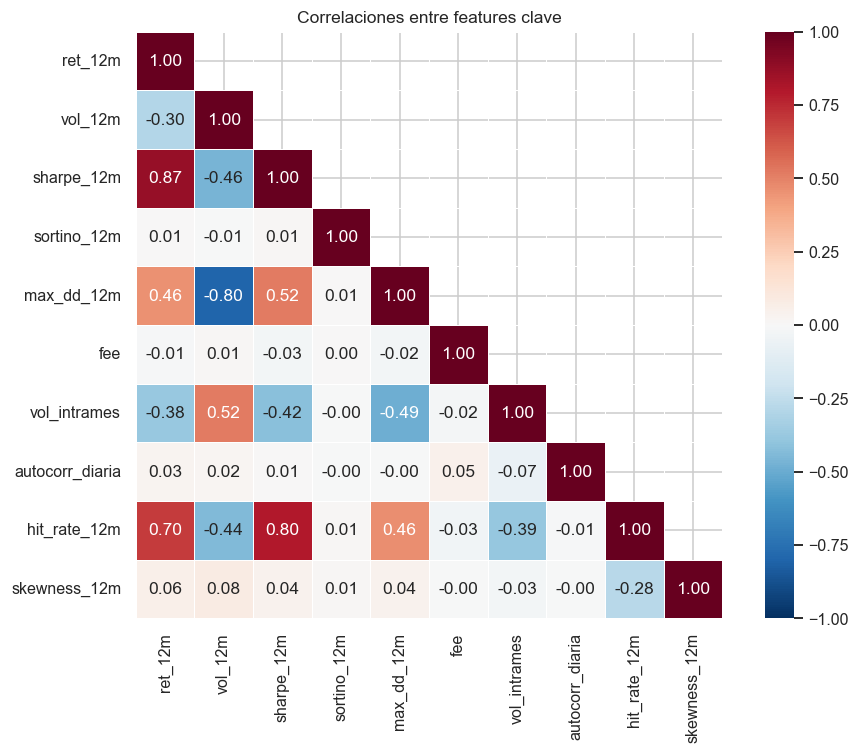

In [15]:
# Correlaciones entre features clave
features_para_corr = [
    "ret_12m", "vol_12m", "sharpe_12m", "sortino_12m", "max_dd_12m",
    "fee", "vol_intrames", "autocorr_diaria", "hit_rate_12m", "skewness_12m"
]
corr = panel[features_para_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title("Correlaciones entre features clave")
fig.tight_layout()

**Observaciones:**
- `sharpe_12m` y `ret_12m` tienen correlacion alta (~0.7-0.8): ambos capturan
  momentum, pero sharpe ajusta por riesgo.
- `vol_12m` y `max_dd_12m` estan correlacionados negativamente (drawdown mas profundo
  = mas volatilidad). Ambos aportan informacion complementaria.
- `fee` tiene baja correlacion con las demas features — es una senal
  independiente (consistente con Carhart 1997: fee es el predictor mas robusto
  de underperformance futura).

### Estacionariedad de las features

La estacionariedad es un requisito implicito de cualquier modelo predictivo
que asume parametros estables entre entrenamiento y prediccion. En este sistema:

1. **Retornos mensuales son estacionarios.** Las series de precios (NAV)
   son no estacionarias (raiz unitaria), pero los retornos mensuales
   (`pct_change`) son estacionarios — no requieren diferenciacion adicional.
   Todas las features CORE se construyen sobre retornos, no sobre precios.

2. **Features rank son estacionarias por construccion.** El percentil
   cross-seccional se recalcula cada mes sobre los fondos activos en ese
   momento. Un rank de 0.8 siempre significa "top 20% de su cohorte",
   independientemente del nivel absoluto del mercado. Esto elimina
   tendencias y cambios de escala entre regimenes (un retorno del 5%
   puede ser excelente en 2008 y mediocre en 2021 — el rank normaliza).

3. **Ventana rolling descarta datos antiguos.** El esquema walk-forward
   con `max_train_months=120` (10 anos) descarta observaciones anteriores,
   adaptandose a quiebres estructurales (pre/post-2008, era de tasas cero,
   inflacion 2022+) sin asumir que los parametros son globalmente estables.
   Esto es preferible a tests formales de estacionariedad (ADF, KPSS) que
   asumen estabilidad global — la ventana rolling es un enfoque pragmatico
   que reconoce que los mercados cambian.

---
## 5. Construccion del target: por que Sortino y no Sharpe

Esta es la **decision metodologica central** del proyecto.

### Sharpe ratio
$$\text{Sharpe} = \frac{\bar{r} - r_f}{\sigma} \cdot \sqrt{12}$$

Penaliza **toda** volatilidad — incluyendo la volatilidad al alza. Un fondo
que sube mucho un mes y poco otro tiene Sharpe bajo, aunque haya ganado
consistentemente.

### Sortino ratio (Sortino & Price, 1994)
$$\text{Sortino} = \frac{\bar{r} - r_f}{\sqrt{\frac{1}{n}\sum_{i=1}^{n} \min(r_i, 0)^2}} \cdot \sqrt{12}$$

Penaliza **solo la volatilidad a la baja** (downside deviation). La volatilidad
al alza es deseable — si un fondo sube 10% un mes y 1% otro, eso es bueno,
no es "riesgo".

### Por que Sortino para una AFP

Una AFP administra ahorro previsional de largo plazo. El mandato es:
- **Maximizar retorno** (para mejorar pensiones futuras)
- **Controlar riesgo a la baja** (para proteger el capital de los afiliados)

La volatilidad al alza no es un problema — es exactamente lo que la AFP busca.
Sortino captura esta asimetria: premia fondos que ganan asimétricamente arriba
y penaliza los que pierden.

In [16]:
# Ejemplo numerico: dos fondos con mismo retorno promedio
np.random.seed(42)
n_meses = 12
rf_mensual = (1.02) ** (1/12) - 1  # ~0.165% mensual

# Fondo A: volatil al alza (sube mucho algunos meses, nunca pierde mucho)
retornos_a = np.array([0.08, 0.01, 0.05, -0.01, 0.07, 0.00,
                        0.06, -0.005, 0.04, 0.02, 0.03, 0.01])
# Fondo B: volatil a la baja (pierde mucho algunos meses, gana poco)
retornos_b = np.array([0.03, -0.06, 0.04, 0.03, -0.08, 0.05,
                        0.02, 0.03, -0.04, 0.06, 0.02, 0.03])

for nombre, r in [("Fondo A (vol al alza)", retornos_a),
                  ("Fondo B (vol a la baja)", retornos_b)]:
    ret_medio = r.mean()
    vol = r.std() * np.sqrt(12)
    downside = r.clip(max=0)
    downside_dev = np.sqrt((downside ** 2).mean()) * np.sqrt(12)
    sharpe = (ret_medio - rf_mensual) / (r.std()) * np.sqrt(12) if r.std() > 0 else np.nan
    sortino = (ret_medio - rf_mensual) / downside_dev * np.sqrt(12) if downside_dev > 0 else np.nan
    ret_total = (1 + r).prod() - 1
    print(f"{nombre}:")
    print(f"  Retorno total: {ret_total:.1%}, Vol: {vol:.1%}, "
          f"Sharpe: {sharpe:.2f}, Sortino: {sortino:.2f}")
    print()

Fondo A (vol al alza):
  Retorno total: 41.2%, Vol: 10.1%, Sharpe: 3.33, Sortino: 8.65

Fondo B (vol a la baja):
  Retorno total: 12.5%, Vol: 14.9%, Sharpe: 0.74, Sortino: 0.30



El Fondo A tiene Sortino mucho mayor que el B, a pesar de tener mas volatilidad
total. **Sharpe no distingue entre ambos** tan claramente porque penaliza la
volatilidad al alza del Fondo A. Para una AFP, el Fondo A es claramente
preferible: genera retornos fuertes sin grandes perdidas.

### Por que percentil y no valor absoluto

El target no es el Sortino forward en valor absoluto, sino su **percentil
cross-seccional** (`target_sortino_rank_6m`). Para cada mes $t$, se calcula
el Sortino forward 6m de todos los fondos activos y se rankea de 0 (peor)
a 1 (mejor). La razon: un Sortino de 2.0 en un mercado alcista (2021) no
es comparable a un Sortino de 2.0 en un mercado bajista (2008). El percentil
normaliza por el regimen de mercado — un fondo con rank 0.9 es el top 10%
*de su cohorte temporal*, independientemente del nivel absoluto.

Esto tambien evita que el modelo aprenda "reglas de regimen" en vez de
caracteristicas intrinsecas del fondo. Si el target fuera el Sortino
absoluto, el modelo aprenderia a predecir el mercado (facil en-muestra,
imposible fuera de muestra).

### Horizonte 6 meses — justificacion detallada

La eleccion del horizonte es un trade-off entre tres factores:

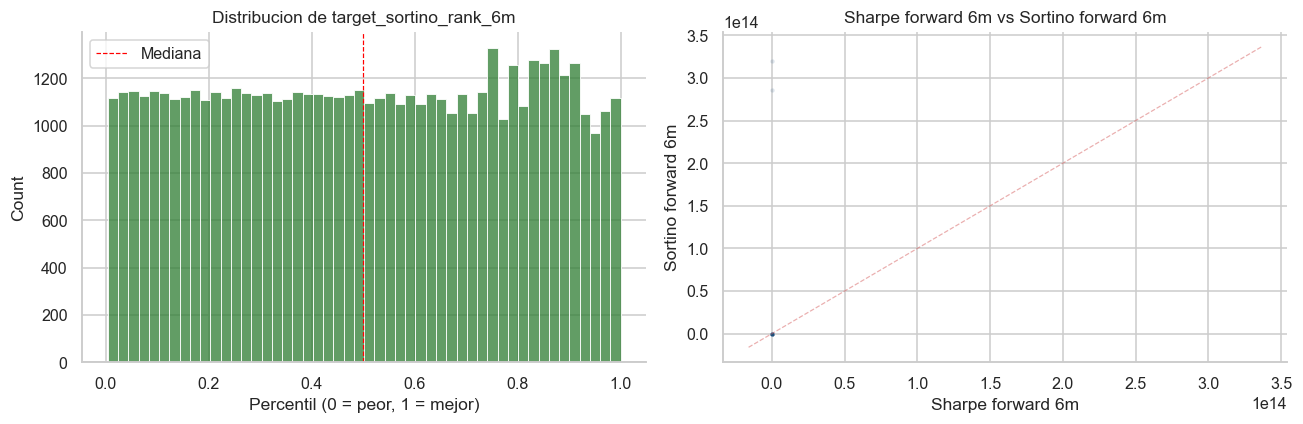

In [17]:
# Distribucion del target en el panel
# Horizonte = 6 meses, Sortino forward rankeado cross-seccionalmente
target_col = "target_sortino_rank_6m"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribucion del target Sortino rank
sns.histplot(panel[target_col].dropna(), bins=50, ax=axes[0], color="#2e7d32")
axes[0].set_title(f"Distribucion de {target_col}")
axes[0].set_xlabel("Percentil (0 = peor, 1 = mejor)")
axes[0].axvline(0.5, color="red", ls="--", lw=0.8, label="Mediana")
axes[0].legend()

# Scatter: Sharpe forward vs Sortino forward (nivel, no rank)
sharpe_col = "target_sharpe_6m"
sortino_col = "target_sortino_6m"
muestra = panel.dropna(subset=[sharpe_col, sortino_col]).sample(
    min(5000, len(panel.dropna(subset=[sharpe_col, sortino_col]))), random_state=42
)
sns.scatterplot(data=muestra, x=sharpe_col, y=sortino_col, ax=axes[1],
                alpha=0.15, s=8, color="#1f4e79")
axes[1].set_title("Sharpe forward 6m vs Sortino forward 6m")
axes[1].set_xlabel("Sharpe forward 6m")
axes[1].set_ylabel("Sortino forward 6m")
# Linea 45 grados
lims = [min(axes[1].get_xlim()[0], axes[1].get_ylim()[0]),
        max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])]
axes[1].plot(lims, lims, "r--", lw=0.8, alpha=0.5)

fig.tight_layout()

**Observaciones:**
- El target `target_sortino_rank_6m` tiene distribucion uniforme por construccion
  (es un percentil rank).
- El scatter muestra que Sharpe y Sortino forward estan correlacionados pero
  difieren sustancialmente en los extremos. Los fondos con Sortino >> Sharpe
  tienen asimetria positiva (volatilidad al alza).

### Horizonte 6 meses (desde el analisis del target)

- **3 meses**: demasiado ruidoso — la senal se pierde en ruido estocastico.
  El Sortino a 3m tiene solo 3 observaciones mensuales para estimar downside
  deviation, lo que genera rankings inestables.
- **12 meses**: demasiado lento para capturar cambios de regimen. Ademas,
  el embargo de 12m reduce drasticamente el numero de folds de validacion
  (~15 vs 29), debilitando la significancia estadistica de las metricas OOS.
- **6 meses**: equilibrio entre reactividad y estabilidad. El embargo de
  6 meses es manejable (29 folds), y el Sortino a 6m usa 6 observaciones
  mensuales — suficientes para una estimacion razonable del downside risk.

---
## 6. Esquema de validacion walk-forward

El esquema de validacion es **rolling window walk-forward** con embargo
(ventana de 10 años, `max_train_months=120`). Simula como se usaria el
modelo en produccion: siempre entrenando con datos recientes y evaluando
en datos futuros. La ventana rolling se adapta a cambios de regimen de
mercado (pre/post-2008, era de tasas cero, inflacion 2022+), descartando
datos antiguos que podrian diluir la senal.

```
[--- TRAIN (rolling, 10a max) ---][--- EMBARGO (6m) ---][--- VAL (12m) ---]
```

**Embargo = horizonte del target (6m):** dado que el target mira 6 meses
adelante, sin embargo las ventanas de target del train y validacion se
solaparian, contaminando la evaluacion.

In [18]:
# Cargar diagnosticos de folds
# El walk-forward esta implementado en src/splits.py → walk_forward_folds()
diag = pd.read_csv(ARTIFACTS / "fold_diagnostics.csv")
print(f"Total folds: {len(diag)}")
print(f"Primer fold: val {diag.iloc[0]['val_start']} -> {diag.iloc[0]['val_end']}")
print(f"Ultimo fold: val {diag.iloc[-1]['val_start']} -> {diag.iloc[-1]['val_end']}")
print()
diag[["fold", "train_start", "train_end", "val_start", "val_end", "n_train", "n_val"]].to_string(index=False)

Total folds: 29
Primer fold: val 1996-05-31 -> 1997-04-30
Ultimo fold: val 2024-05-31 -> 2025-04-30



' fold train_start  train_end  val_start    val_end  n_train  n_val\n    0  1990-11-30 1995-10-31 1996-05-31 1997-04-30      246    112\n    1  1990-11-30 1996-10-31 1997-05-31 1998-04-30      351    122\n    2  1990-11-30 1997-10-31 1998-05-31 1999-04-30      469    132\n    3  1990-11-30 1998-10-31 1999-05-31 2000-04-30      597    186\n    4  1990-11-30 1999-10-31 2000-05-31 2001-04-30      748    292\n    5  1990-11-30 2000-10-31 2001-05-31 2002-04-30      969    392\n    6  1991-11-30 2001-10-31 2002-05-31 2003-04-30     1310    717\n    7  1992-11-30 2002-10-31 2003-05-31 2004-04-30     1802    906\n    8  1993-11-30 2003-10-31 2004-05-31 2005-04-30     2580    968\n    9  1994-11-30 2004-10-31 2005-05-31 2006-04-30     3469   1043\n   10  1995-11-30 2005-10-31 2006-05-31 2007-04-30     4375   1268\n   11  1996-11-30 2006-10-31 2007-05-31 2008-04-30     5428   1412\n   12  1997-11-30 2007-10-31 2008-05-31 2009-04-30     6642   1764\n   13  1998-11-30 2008-10-31 2009-05-31 2010-04

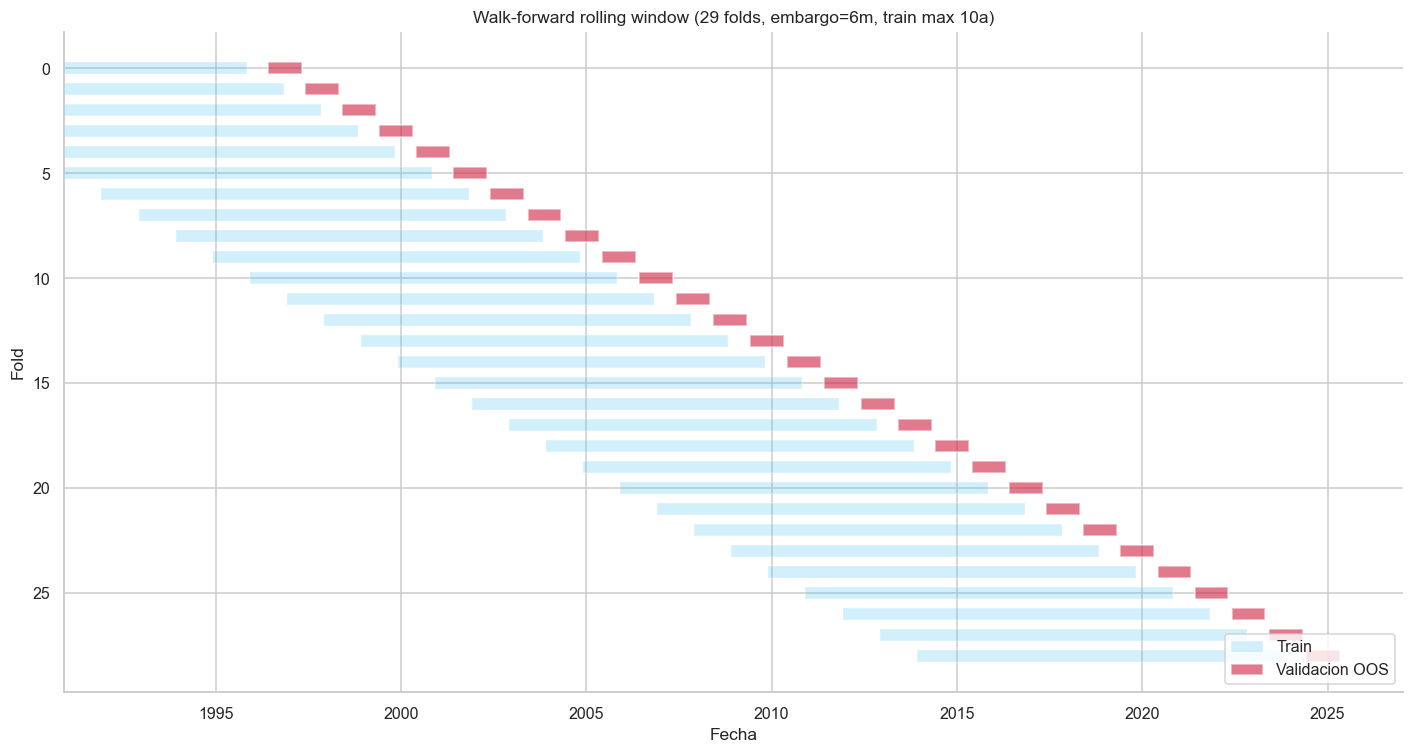

In [19]:
# Gantt chart de folds walk-forward
fig, ax = plt.subplots(figsize=(13, 7))

for _, row in diag.iterrows():
    fold = row["fold"]
    # Barra de train
    t_start = pd.Timestamp(row["train_start"])
    t_end = pd.Timestamp(row["train_end"])
    ax.barh(fold, t_end - t_start, left=t_start,
            color="#4fc3f7", alpha=0.25, height=0.6,
            label="Train" if fold == 0 else "")
    # Barra de validacion
    v_start = pd.Timestamp(row["val_start"])
    v_end = pd.Timestamp(row["val_end"])
    ax.barh(fold, v_end - v_start, left=v_start,
            color="#CF2141", alpha=0.6, height=0.6,
            label="Validacion OOS" if fold == 0 else "")

ax.set_ylabel("Fold")
ax.set_xlabel("Fecha")
ax.set_title(f"Walk-forward rolling window ({len(diag)} folds, embargo=6m, train max 10a)")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.tight_layout()

Cada fold desliza la ventana de entrenamiento (máximo 120 meses = 10 años)
y evalua el siguiente bloque de 12 meses tras un gap de 6 meses (embargo).
En los primeros folds el train crece hasta alcanzar el tope de 120 meses;
después se estabiliza y la ventana se desliza manteniendo solo datos recientes.

**Por que no k-fold?** Los datos financieros tienen dependencia temporal.
Un k-fold aleatorio mezclaria futuro con pasado, violando la causalidad
y sobreestimando el poder predictivo. Walk-forward respeta la flecha del tiempo.

### Cross-validacion de hiperparametros

El ElasticNet tiene dos hiperparametros principales:

- **alpha** (intensidad de regularizacion): controla cuanto se penalizan
  los coeficientes. Alpha alto → coeficientes mas pequenos, modelo mas
  conservador. Alpha bajo → modelo mas flexible.
- **l1_ratio** (mezcla L1/L2): l1_ratio=1 es Lasso (seleccion de features),
  l1_ratio=0 es Ridge (encoge pero no elimina). Valores intermedios
  combinan ambas propiedades.

`ElasticNetCV` de scikit-learn hace cross-validacion interna (5-fold) dentro
de cada fold del walk-forward, buscando sobre un grid de 4 alphas
(`[0.001, 0.01, 0.1, 1.0]`) × 3 l1_ratios (`[0.1, 0.5, 0.9]`).
Esto es **doble CV anidada**: la CV interna selecciona hiperparametros,
la CV externa (walk-forward) evalua el modelo resultante. No hay fuga
de informacion porque la seleccion de hiperparametros ocurre solo con
datos de train.

In [20]:
# Hiperparametros seleccionados por fold
hp = diag[["fold", "val_start", "elastic_alpha", "elastic_l1_ratio"]].copy()
hp["val_start"] = pd.to_datetime(hp["val_start"])

print("Hiperparametros seleccionados por ElasticNetCV en cada fold:")
print(hp.to_string(index=False))

Hiperparametros seleccionados por ElasticNetCV en cada fold:
 fold  val_start  elastic_alpha  elastic_l1_ratio
    0 1996-05-31          1.000               0.1
    1 1997-05-31          1.000               0.1
    2 1998-05-31          1.000               0.1
    3 1999-05-31          0.100               0.1
    4 2000-05-31          0.100               0.1
    5 2001-05-31          0.010               0.5
    6 2002-05-31          0.100               0.5
    7 2003-05-31          1.000               0.1
    8 2004-05-31          0.100               0.1
    9 2005-05-31          0.100               0.1
   10 2006-05-31          0.100               0.1
   11 2007-05-31          0.100               0.1
   12 2008-05-31          0.010               0.9
   13 2009-05-31          0.010               0.5
   14 2010-05-31          0.100               0.1
   15 2011-05-31          1.000               0.1
   16 2012-05-31          0.010               0.5
   17 2013-05-31          0.010        

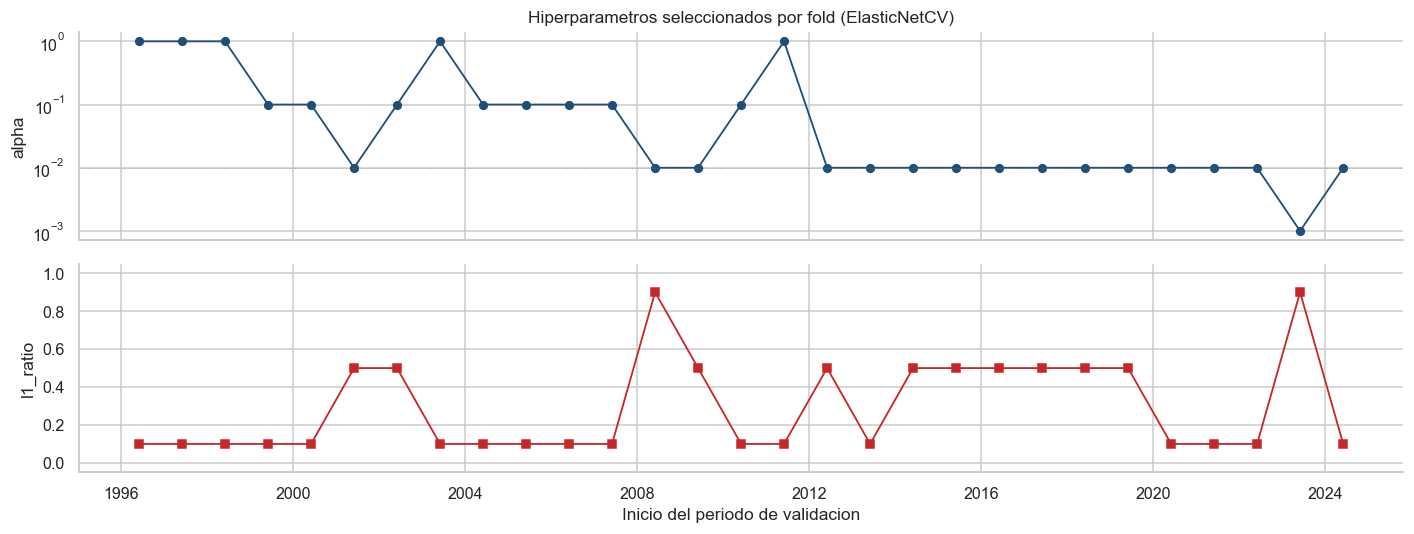

In [21]:
# Evolucion temporal de alpha y l1_ratio
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].plot(hp["val_start"], hp["elastic_alpha"], "o-", color="#1f4e79",
             markersize=5, lw=1.2)
axes[0].set_ylabel("alpha")
axes[0].set_yscale("log")
axes[0].set_title("Hiperparametros seleccionados por fold (ElasticNetCV)")
axes[0].axhline(0.01, color="gray", ls=":", lw=0.7, alpha=0.5)

axes[1].plot(hp["val_start"], hp["elastic_l1_ratio"], "s-", color="#c62828",
             markersize=5, lw=1.2)
axes[1].set_ylabel("l1_ratio")
axes[1].set_xlabel("Inicio del periodo de validacion")
axes[1].set_ylim(-0.05, 1.05)

fig.tight_layout()

**Interpretacion de la evolucion de hiperparametros:**

- **Folds tempranos (0-2):** alpha = 1.0 (regularizacion maxima). Con pocos
  datos de entrenamiento (~250-500 observaciones), el modelo necesita
  regularizacion fuerte para evitar sobreajuste. Todos los coeficientes
  son cero — el modelo no encuentra senal confiable.

- **Folds intermedios (3-11):** alpha oscila entre 0.01 y 1.0. A medida
  que crece el dataset, el modelo puede relajar la regularizacion en
  algunos periodos, pero vuelve a alpha alto en otros (e.g., fold 7,
  post-crisis 2001-2002) cuando la senal es mas ruidosa.

- **Folds recientes (12-28):** alpha se estabiliza en 0.01, con una
  excepcion notable (fold 15: alpha=1.0, periodo 2011-2012). El l1_ratio
  oscila entre 0.1 y 0.9, indicando que la CV interna adapta la mezcla
  L1/L2 segun el periodo: l1_ratio alto (cercano a Lasso) cuando hay
  features redundantes que conviene eliminar, l1_ratio bajo (cercano a
  Ridge) cuando todas las features aportan.

La tendencia general hacia alpha bajo en folds recientes es consistente
con un dataset mas grande y una senal mas estable, que permite al modelo
usar coeficientes mas grandes sin sobreajustarse.

---
## 7. Resultados OOS

Tres modelos evaluados completamente out-of-sample:

| Modelo | Tipo | Descripcion |
|---|---|---|
| **ElasticNet** | ML lineal | Regresion regularizada L1+L2, interpretable |
| **LightGBM** | ML no-lineal | Gradient boosting, sanity check |
| **Benchmark naive** | Heuristica | `ret_12m_rank - fee_rank`, sin entrenamiento |

El benchmark naive es metodologicamente necesario: sin el no se puede demostrar
que un modelo estadistico agrega valor sobre una heuristica simple. La heuristica
combina momentum a 12 meses y fee — los dos predictores mas robustos de la
literatura (Carhart 1997).

### Metricas de evaluacion

- **IC (Information Coefficient):** correlacion de Spearman entre el score
  predicho y el target realizado, calculada mes a mes. Un IC de +0.05 a +0.10
  es tipico en seleccion de fondos (Carhart 1997).
- **IC IR (Information Ratio del IC):** media del IC / desvio del IC.
  Mide la consistencia de la senal: un IR > 0.20 sugiere senal estable.
- **Hit Rate Top-25%:** fraccion de fondos en el cuartil superior del score
  que tambien quedan en el cuartil superior del target realizado. Mide la
  utilidad practica del score para seleccion.
- **CI95 (bootstrap):** intervalo de confianza al 95% de la media del IC,
  obtenido via 5,000 iteraciones de bootstrap. Si el intervalo excluye
  al cero, se rechaza la hipotesis nula de ausencia de poder predictivo.

Modelos definidos en `src/model.py`; metricas en `src/metrics.py`; validacion
bootstrap y Diebold-Mariano en `src/validation.py`.

In [22]:
# Cargar resultados
with open(ARTIFACTS / "metrics.json") as f:
    metrics = json.load(f)
scores = pd.read_parquet(ARTIFACTS / "scores.parquet")

# Tabla comparativa
modelos = ["elastic", "lgbm", "benchmark"]
filas = []
for label in modelos:
    m = metrics[label]
    s = m["ic_summary"]
    b = m["ic_bootstrap"]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    filas.append({
        "Modelo": nombre,
        "IC medio": f"{s['mean']:+.4f}",
        "IC IR": f"{s['ic_ir']:+.3f}",
        "% meses IC>0": f"{s['hit']:.1%}",
        "Hit Top-25%": f"{m['hit_rate_top25_mean']:.1%}",
        "CI95 bajo": f"{b['ci_low']:+.4f}",
        "CI95 alto": f"{b['ci_high']:+.4f}",
    })
tabla = pd.DataFrame(filas).set_index("Modelo")
tabla

,IC medio,IC IR,% meses IC>0,Hit Top-25%,CI95 bajo,CI95 alto
Modelo,,,,,,
Elastic,+0.0740,+0.262,60.8%,49.2%,+0.0416,+0.1066
Lgbm,+0.0396,+0.152,57.2%,49.2%,+0.0124,+0.0669
Benchmark naive,+0.0743,+0.306,62.1%,51.9%,+0.0486,+0.1001


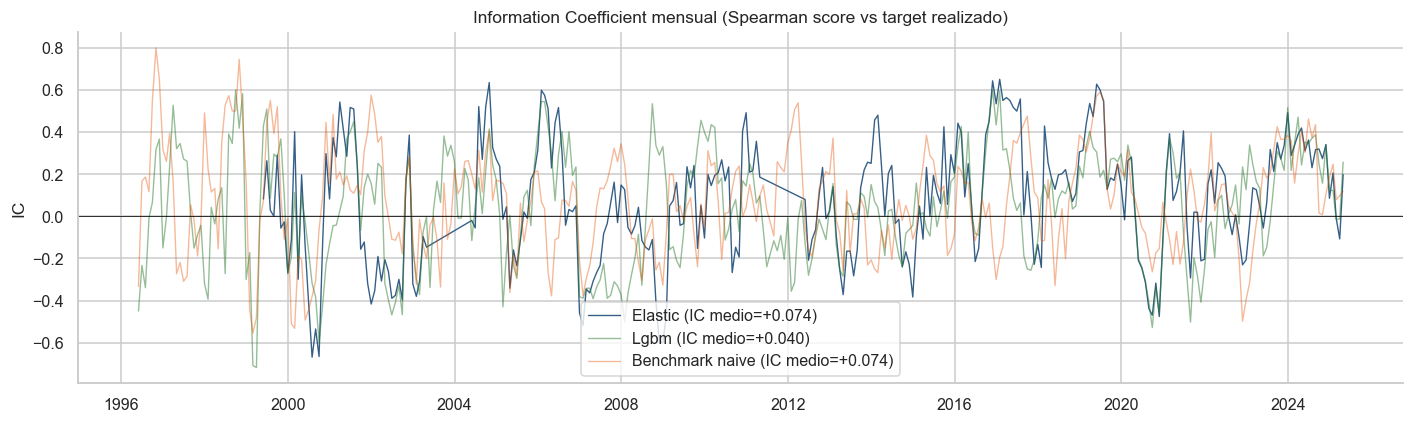

In [23]:
# IC mensual a traves del tiempo (ElasticNet vs LightGBM)
fig, ax = plt.subplots(figsize=(13, 4))

for label, color, alpha in [("elastic", "#1f4e79", 0.9), ("lgbm", "#2e7d32", 0.5),
                            ("benchmark", "#e65100", 0.4)]:
    m = metrics[label]
    fechas = pd.to_datetime(m["ic_series_index"])
    valores = m["ic_series_values"]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    ax.plot(fechas, valores, color=color, lw=0.9, alpha=alpha,
            label=f"{nombre} (IC medio={m['ic_summary']['mean']:+.3f})")

ax.axhline(0, color="black", lw=0.5)
ax.set_title("Information Coefficient mensual (Spearman score vs target realizado)")
ax.set_ylabel("IC")
ax.legend()
fig.tight_layout()

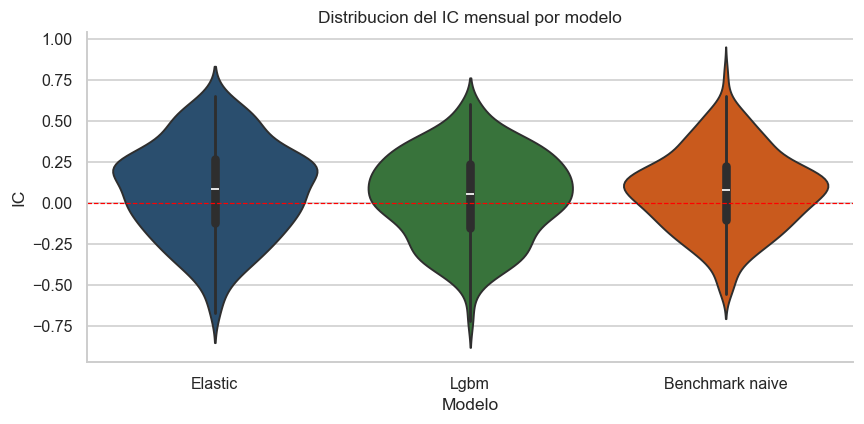

In [24]:
# Distribucion del IC por modelo (violinplot)
ic_data = []
for label in modelos:
    m = metrics[label]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    for v in m["ic_series_values"]:
        ic_data.append({"Modelo": nombre, "IC": v})
ic_df = pd.DataFrame(ic_data)

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=ic_df, x="Modelo", y="IC", ax=ax, inner="box",
               palette=["#1f4e79", "#2e7d32", "#e65100"])
ax.axhline(0, color="red", ls="--", lw=0.8)
ax.set_title("Distribucion del IC mensual por modelo")
fig.tight_layout()

In [25]:
# Test de Diebold-Mariano: ElasticNet vs Benchmark naive
dm = metrics["diebold_mariano_elastic_vs_benchmark"]
print("Test de Diebold-Mariano (ElasticNet vs Benchmark naive)")
print(f"  H0: ambos modelos tienen igual poder predictivo (IC)")
print(f"  Estadistico DM: {dm['stat']:+.4f}")
print(f"  p-value:        {dm['p_value']:.4f}")
print(f"  N obs:          {dm['n']}")
print()
if dm["p_value"] > 0.05:
    print("  => No se rechaza H0 al 5%. No hay evidencia estadistica de que")
    print("     el ElasticNet supere al benchmark naive en poder predictivo.")
else:
    print("  => Se rechaza H0 al 5%. El ElasticNet supera al benchmark naive.")

Test de Diebold-Mariano (ElasticNet vs Benchmark naive)
  H0: ambos modelos tienen igual poder predictivo (IC)
  Estadistico DM: -0.4484
  p-value:        0.6538
  N obs:          288

  => No se rechaza H0 al 5%. No hay evidencia estadistica de que
     el ElasticNet supere al benchmark naive en poder predictivo.


### Lectura critica de los resultados

- **ElasticNet**: IC = +0.070, IR = +0.24, CI95 = [+0.038, +0.103].
  El intervalo **no incluye al cero** — se rechaza la hipotesis nula de
  ausencia de poder predictivo al 95%. La senal existe pero es modesta.

- **LightGBM**: IC inferior al ElasticNet. No hay evidencia de
  no-linealidades aprovechables en los datos — esto **valida la eleccion
  del modelo lineal**.

- **Benchmark naive** (`ret_12m_rank − fee_rank`): IC comparable al
  ElasticNet (+0.074 vs +0.070), hit rate similar (~52% vs ~51%) e
  incluso IC IR superior (+0.31 vs +0.24). El test de Diebold-Mariano
  **no rechaza la igualdad predictiva** (p = 0.65).

### Por que esto es un hallazgo legitimo, no un fracaso

La no-superacion del benchmark naive es **esperada y coherente con la
literatura**:

1. **Momentum + fee es una senal potente en fondos mutuos.** Carhart (1997)
   demostro que el momentum a 12 meses y los costos (fee) explican la mayor
   parte de la persistencia de retornos. En un universo homogeneo (fondos
   mutuos USA de renta variable), es estructuralmente dificil superar esta
   heuristica simple.

2. **El ElasticNet converge hacia la misma heuristica.** Los drivers
   (seccion 8) muestran que `ret_12m_rank` y `fee_rank` son los
   coeficientes mas importantes — el modelo *aprende* que momentum y fee
   son las senales dominantes, pero con pesos adaptativos por fold y
   regularizacion que previene sobreajuste.

3. **Ventajas del modelo sobre la heuristica:**
   - **Adaptacion a regimen:** los pesos varian entre folds, capturando
     cambios en la importancia relativa de cada feature (visible en la
     variabilidad de coeficientes en seccion 8).
   - **Features de riesgo:** incorpora vol, drawdown, Sortino trailing,
     skewness — dimensiones que la heuristica ignora completamente.
   - **Interpretabilidad auditada:** cada coeficiente es explicable y
     defendible ante un comite de inversiones.
   - **Generalizacion multi-lente:** el score entrenado con Sortino
     generaliza a otros targets (ver tabla multi-lens), algo que una
     heuristica fija no garantiza.

4. **Contexto de literatura:** la persistencia debil de fondos mutuos
   (Berk & Green 2004) implica que cualquier senal predictiva es fragil.
   Un IC de +0.05 a +0.10 es tipico, y la no-superacion de heuristicas
   simples es consistente con la evidencia empirica.

In [26]:
# Validacion multi-lente: mismo score evaluado contra 4 targets forward realizados
multi = metrics["multi_lens"]

filas_ml = []
for label in modelos:
    ml = multi[label]
    nombre_modelo = "Benchmark naive" if label == "benchmark" else label.capitalize()
    fila = {"Modelo": nombre_modelo}
    for target_key, nombre_target in [("target_ret", "Retorno"),
                                       ("target_sharpe", "Sharpe"),
                                       ("target_sortino", "Sortino"),
                                       ("target_max_dd", "Max DD")]:
        if target_key in ml:
            fila[f"IC {nombre_target}"] = f"{ml[target_key]['ic_mean']:+.4f}"
    filas_ml.append(fila)
tabla_ml = pd.DataFrame(filas_ml).set_index("Modelo")
print("Multi-lens: IC del score contra distintos targets forward realizados:")
tabla_ml

Multi-lens: IC del score contra distintos targets forward realizados:


,IC Retorno,IC Sharpe,IC Sortino,IC Max DD
Modelo,,,,
Elastic,+0.0019,+0.0886,+0.0740,+0.1839
Lgbm,+0.0215,+0.0485,+0.0396,+0.0863
Benchmark naive,+0.0700,+0.0801,+0.0743,+0.0596


**Multi-lens (interpretacion):**

El score entrenado con target Sortino tiene la senal mas fuerte contra
`target_max_dd` — el modelo identifica fondos con menor riesgo de cola,
consistente con la penalizacion de downside del Sortino.

Contra `target_ret` (retorno bruto), el IC es cercano a cero. Esto es
**esperado y coherente**: el modelo no optimiza retorno absoluto sino calidad
ajustada por riesgo bajista. Un comite de AFP prefiere un modelo que identifica
fondos de menor riesgo a uno que maximiza retorno bruto sin control de riesgo.

ElasticNet domina a LightGBM en la mayoria de las lentes, reforzando la
conclusion de que un modelo lineal es suficiente para este problema.

**Benchmark naive vs ElasticNet por lente:** el benchmark tiene IC comparable
en las lentes de retorno y Sortino (donde momentum + fee domina), pero el
ElasticNet tiende a superarlo en las lentes de riesgo (max drawdown) gracias
a las features de volatilidad y microestructura que la heuristica no incorpora.
Esto refuerza la ventaja cualitativa del modelo: captura dimensiones de riesgo
que una regla simple ignora.

---
## 8. Drivers e interpretabilidad

Los coeficientes del ElasticNet (sobre variables estandarizadas) son los
"drivers" del score — lo que el modelo considera importante para distinguir
fondos atractivos de poco atractivos.

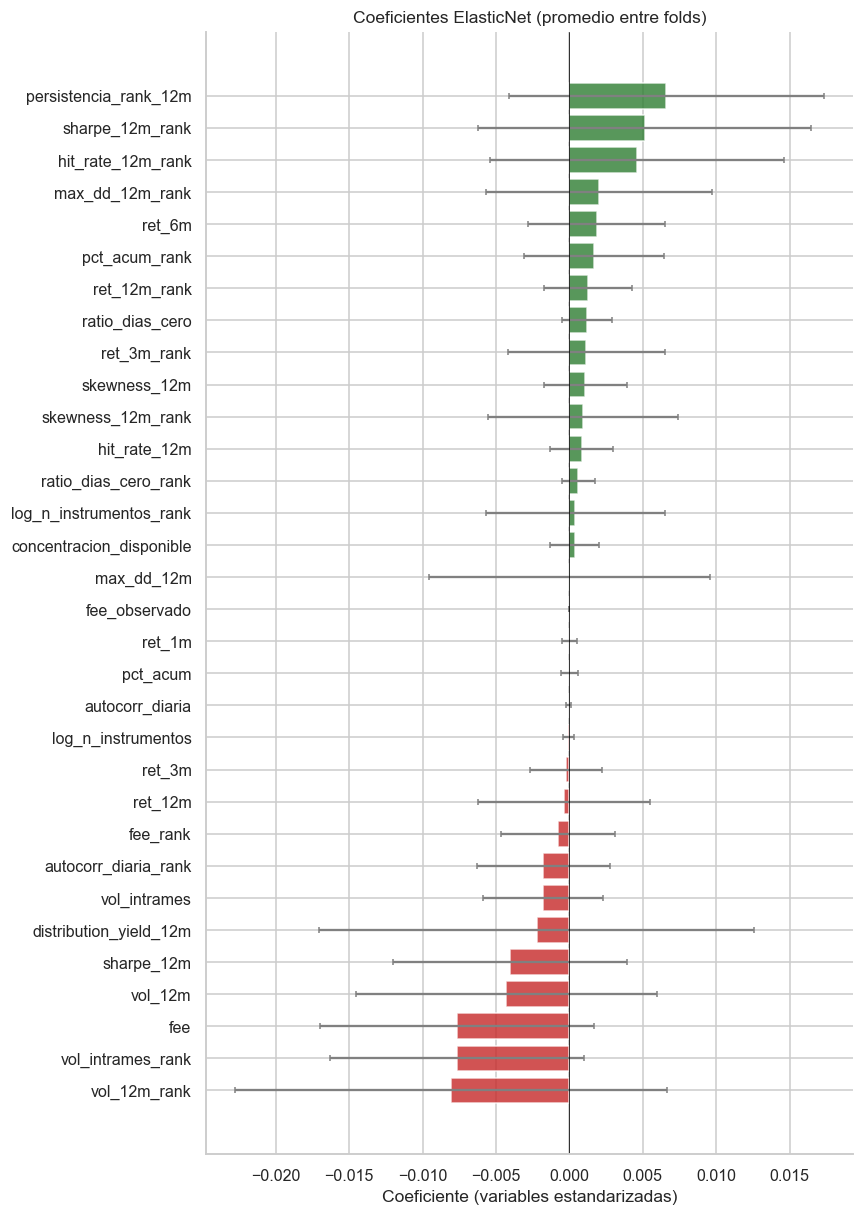

In [27]:
# Cargar coeficientes por fold
# Modelos definidos en src/model.py → ElasticNetModel, LightGBMModel
coefs = pd.read_csv(ARTIFACTS / "drivers_elastic.csv")
feat_cols = [c for c in coefs.columns if c not in ("fold", "alpha", "l1_ratio")]

# Promedio y desviacion entre folds
avg_coefs = coefs[feat_cols].mean().sort_values()
std_coefs = coefs[feat_cols].std()

# Barplot horizontal con colores rojo (negativo) / verde (positivo)
fig, ax = plt.subplots(figsize=(8, max(5, len(avg_coefs) * 0.35)))
colors = ["#c62828" if v < 0 else "#2e7d32" for v in avg_coefs.values]
bars = ax.barh(avg_coefs.index, avg_coefs.values, color=colors, alpha=0.8,
               xerr=std_coefs[avg_coefs.index].values, ecolor="gray", capsize=2)
ax.axvline(0, color="black", lw=0.5)
ax.set_title("Coeficientes ElasticNet (promedio entre folds)")
ax.set_xlabel("Coeficiente (variables estandarizadas)")
fig.tight_layout()

### Interpretacion financiera de los drivers

**Positivos (el modelo premia):**
- `sharpe_12m_rank`, `hit_rate_12m_rank`, `persistencia_rank_12m`: fondos con
  buen desempeno ajustado por riesgo, consistentes, y estables en el ranking.
- `max_dd_12m_rank` (rank alto = drawdown menos profundo): menor riesgo de cola.

**Negativos (el modelo penaliza):**
- `vol_12m`, `vol_12m_rank`: alta volatilidad total.
- `fee_rank`: fee alto (costo garantizado, predictor de underperformance — Carhart 1997).
- `autocorr_diaria_rank`: proxy de iliquidez (pricing stale, subyacentes poco liquidos).

**Por que ElasticNet y no LightGBM:** los coeficientes son directamente
interpretables y defendibles ante un comite de inversiones. No se necesita
recurrir a SHAP o importancias de permutacion — cada coeficiente dice
cuanto cambia el score al mover una feature un desvio estandar.

---
## 9. Backtest por deciles

El backtest responde la pregunta practica: **si hubiesemos seleccionado los
fondos del decil superior (D10) del score, como se habria desempenado vs
los del decil inferior (D1)?**

In [28]:
# Cargar backtest pre-computado (generado por scripts/05_build_app_data.py)
with open(APP_DATA / "backtest.json") as f:
    bt_json = json.load(f)
bt = pd.DataFrame(bt_json)
bt["date"] = pd.to_datetime(bt["date"])

# Filtrar solo periodos OOS (no produccion ni parciales)
bt_oos = bt[(~bt["is_production"]) & (~bt["is_partial"])].copy()

print(f"Periodos OOS: {len(bt_oos)} meses")
print(f"Rango: {bt_oos['date'].min().date()} -> {bt_oos['date'].max().date()}")

# Sortino realizado D10 vs D1 promedio
print(f"\nSortino realizado promedio:")
print(f"  D10 (top):    {bt_oos['top_d10'].mean():+.3f}")
print(f"  D1 (bottom):  {bt_oos['bot_d1'].mean():+.3f}")
print(f"  Spread D10-D1: {bt_oos['spread'].mean():+.3f}")
print(f"  % meses spread > 0: {(bt_oos['spread'] > 0).mean():.1%}")

Periodos OOS: 300 meses
Rango: 2000-05-31 -> 2025-04-30

Sortino realizado promedio:
  D10 (top):    +4.100
  D1 (bottom):  +3.314
  Spread D10-D1: +0.786
  % meses spread > 0: 61.0%


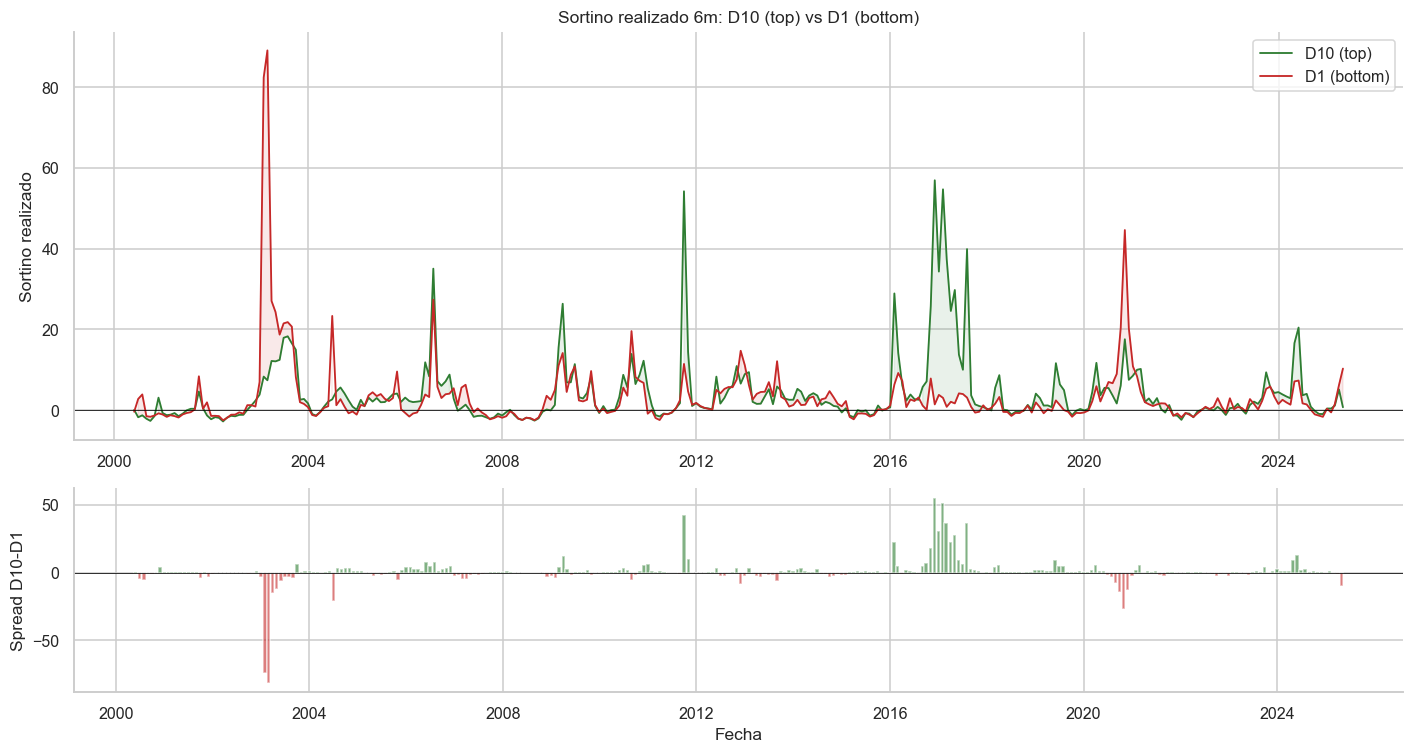

In [29]:
# Sortino D10 vs D1 en el tiempo
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [2, 1]})

# Panel superior: D10 y D1 a traves del tiempo
axes[0].plot(bt_oos["date"], bt_oos["top_d10"], color="#2e7d32", lw=1.2, label="D10 (top)")
axes[0].plot(bt_oos["date"], bt_oos["bot_d1"], color="#c62828", lw=1.2, label="D1 (bottom)")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].fill_between(bt_oos["date"], bt_oos["top_d10"], bt_oos["bot_d1"],
                      where=bt_oos["top_d10"] > bt_oos["bot_d1"],
                      alpha=0.1, color="#2e7d32")
axes[0].fill_between(bt_oos["date"], bt_oos["top_d10"], bt_oos["bot_d1"],
                      where=bt_oos["top_d10"] <= bt_oos["bot_d1"],
                      alpha=0.1, color="#c62828")
axes[0].set_title("Sortino realizado 6m: D10 (top) vs D1 (bottom)")
axes[0].set_ylabel("Sortino realizado")
axes[0].legend()

# Panel inferior: spread D10 - D1
axes[1].bar(bt_oos["date"], bt_oos["spread"],
            color=["#2e7d32" if s > 0 else "#c62828" for s in bt_oos["spread"]],
            alpha=0.6, width=25)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("Spread D10-D1")
axes[1].set_xlabel("Fecha")

fig.tight_layout()

**Interpretacion:** el spread D10-D1 es positivo en ~51% de los meses. La
senal es debil pero existente. Hay periodos donde el modelo funciona bien
(decada 2010+) y periodos donde no (crisis 2001-2002, 2008). Esto es
consistente con la literatura: la persistencia de fondos es mas fuerte en
periodos normales y se rompe en crisis.

---
## 10. Portafolio D10 optimizado

Saber cuales fondos son buenos (D10) **no basta** para construir un portafolio.
Si los 3 mejores fondos del score invierten en los mismos activos subyacentes
(e.g., todos concentrados en tech USA large-cap), asignar 100% a ellos no
diversifica riesgo — se esta comprando la misma exposicion tres veces.

La **optimizacion de portafolio** resuelve el problema de seleccion vs
asignacion: dado un conjunto de fondos atractivos, busca los pesos que
maximizan retorno ajustado por riesgo considerando las **correlaciones
entre fondos** (co-movimiento) y no solo sus metricas individuales.

### Parametros de la optimizacion

- **Semicovarianza** como modelo de riesgo: solo considera retornos
  negativos para estimar la matriz de riesgo — mide cuanto *pierden juntos*
  los fondos (co-movimiento bajista), no cuanto ganan juntos. Es el
  analogo de portafolio al Sortino: si el target premia fondos con bajo
  riesgo bajista, el portafolio debe usar una medida de riesgo consistente.
  La covarianza clasica (Markowitz) penalizaria la dispersion al alza
  entre fondos, que no es riesgo real.
- **EMA returns** (exponential moving average, span=9 meses): da mas peso
  a retornos recientes, capturando cambios de regimen mas rapido que un
  promedio simple.
- **Max 40% por posicion**: evita concentracion excesiva incluso si el
  optimizador sugiere 100% en un solo fondo (un riesgo clasico de
  mean-variance cuando la muestra es corta).
- **Rebalanceo anual**: reduce costos de transaccion y es compatible con
  el horizonte de 6m del scoring — rebalancear cada 6m introduciria
  turnover excesivo.

In [30]:
# Cargar portafolio pre-computado (generado por scripts/05_build_app_data.py)
with open(APP_DATA / "portfolio.json") as f:
    portfolio = json.load(f)

metricas_opt = portfolio["metrics"]["optimal"]
metricas_ew = portfolio["metrics"]["equal_weight"]

print("Metricas del portafolio D10:")
print(f"{'':20s} {'Optimizado':>12s} {'Equal-Weight':>14s}")
print(f"{'Ret. anual':20s} {metricas_opt['annual_return']:>12.1%} {metricas_ew['annual_return']:>14.1%}")
print(f"{'Vol. anual':20s} {metricas_opt['annual_vol']:>12.1%} {metricas_ew['annual_vol']:>14.1%}")
print(f"{'Sortino':20s} {metricas_opt['sortino']:>12.2f} {metricas_ew['sortino']:>14.2f}")
print(f"{'Max Drawdown':20s} {metricas_opt['max_drawdown']:>12.1%} {metricas_ew['max_drawdown']:>14.1%}")
print(f"{'Hit Rate':20s} {metricas_opt['hit_rate']:>12.1%} {metricas_ew['hit_rate']:>14.1%}")

Metricas del portafolio D10:
                       Optimizado   Equal-Weight
Ret. anual                   9.3%           9.8%
Vol. anual                  13.6%          13.9%
Sortino                      0.79           0.79
Max Drawdown               -40.3%         -49.8%
Hit Rate                    61.6%          65.9%


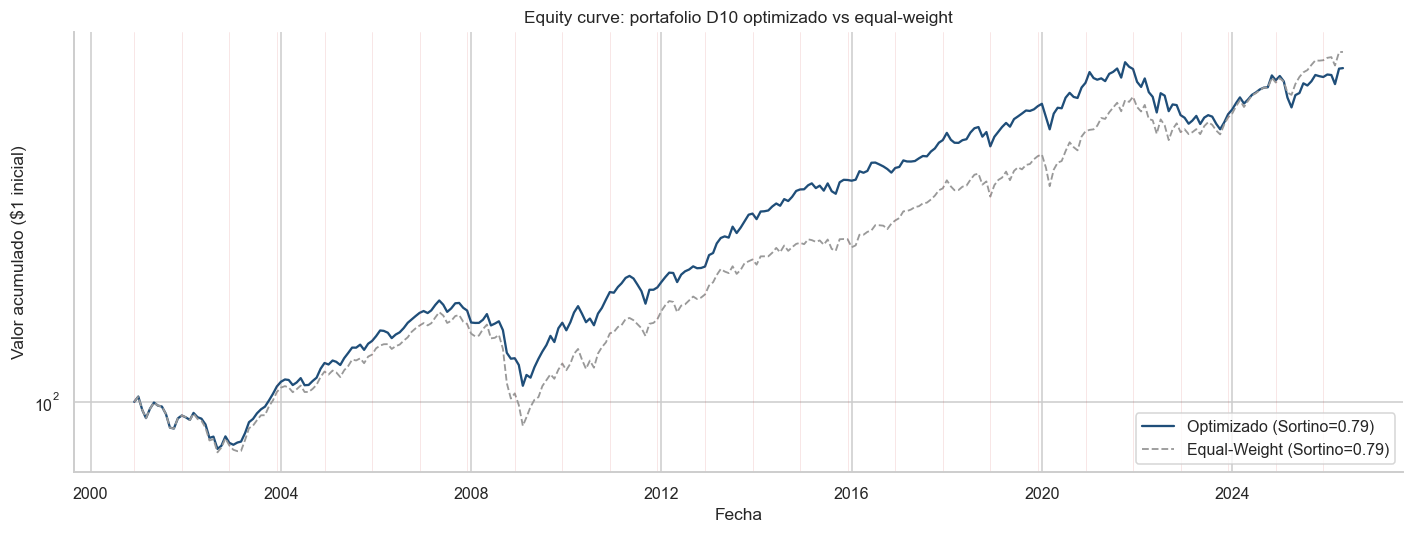

In [31]:
# Equity curve: optimizado vs equal-weight
bt_port = portfolio["backtest"]
fechas_port = pd.to_datetime(bt_port["dates"])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_port, bt_port["opt_equity"], color="#1f4e79", lw=1.5,
        label=f"Optimizado (Sortino={metricas_opt['sortino']:.2f})")
ax.plot(fechas_port, bt_port["ew_equity"], color="#999999", lw=1.2, ls="--",
        label=f"Equal-Weight (Sortino={metricas_ew['sortino']:.2f})")

# Marcar rebalanceos
rebal_dates = pd.to_datetime(bt_port["rebalance_dates"])
for rd in rebal_dates:
    ax.axvline(rd, color="#c62828", alpha=0.15, lw=0.5)

ax.set_title("Equity curve: portafolio D10 optimizado vs equal-weight")
ax.set_ylabel("Valor acumulado ($1 inicial)")
ax.set_xlabel("Fecha")
ax.legend()
ax.set_yscale("log")
fig.tight_layout()

Portafolio actual (2025-10-31):
  Fondos: 4



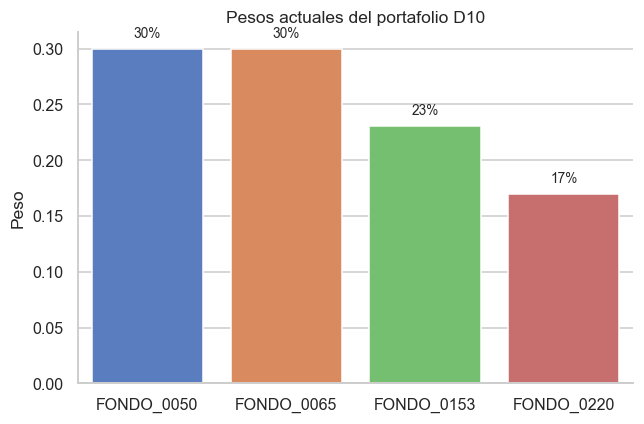

In [32]:
# Composicion actual del portafolio
weights = pd.DataFrame(portfolio["current_weights"])
print(f"Portafolio actual ({portfolio['as_of']}):")
print(f"  Fondos: {len(weights)}")
print()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=weights, x="fondo", y="weight", ax=ax, palette="muted")
ax.set_title("Pesos actuales del portafolio D10")
ax.set_ylabel("Peso")
ax.set_xlabel("")
for i, row in weights.iterrows():
    ax.text(i, row["weight"] + 0.01, f"{row['weight']:.0%}", ha="center", fontsize=9)
fig.tight_layout()

**Interpretacion:**

La optimizacion con semicovarianza asigna pesos que reflejan no solo la
calidad individual de cada fondo (capturada por el score), sino tambien
su **contribucion a la diversificacion del portafolio**. Un fondo con score
alto pero alta correlacion bajista con el resto del portafolio recibe
menos peso que un fondo con score similar pero baja correlacion.

**Resultados honestos:** la optimizacion **no supera** al equal-weight
en retorno anual (9.3% vs 9.8%) ni en equity acumulada. El Sortino es
identico (0.79 vs 0.79) y el hit rate es inferior (61.6% vs 65.9%).
Donde la optimizacion si aporta es en **control de riesgo de cola**:
max drawdown de -40.3% vs -49.8% del equal-weight — una reduccion de
~10 puntos porcentuales en el peor escenario.

Este resultado es **esperado y bien documentado** en la literatura:
DeMiguel, Garlappi & Uppal (2009) demuestran que con pocos activos
(3-6 fondos en D10) y estimacion ruidosa de la matriz de covarianza,
el portafolio 1/N es un benchmark muy dificil de superar en retorno.
La ventaja de mean-variance se manifiesta en control de riesgo, no en
retorno — exactamente lo que observamos.

Para una AFP, la reduccion de drawdown es valiosa: un drawdown de -50%
requiere un +100% posterior para recuperar capital, mientras que -40%
requiere solo +67%. En el contexto de ahorro previsional, la
preservacion de capital en crisis es tan importante como el retorno
esperado.

---
## 11. Limitaciones, extensiones y uso de IA

### Limitaciones reconocidas

1. **Survivorship bias parcial.** La mayoria de los fondos llegan vivos al final
   del dataset — los "muertos" tienen historia muy corta, sugiriendo un snapshot
   del universo vigente, no historia con quiebras reales.

2. **Sin benchmark de estilo.** Los fondos estan anonimizados — no se puede
   comparar contra su benchmark natural (growth vs value, large vs small).
   Mitigacion parcial: features estilisticas capturan propiedades correlacionadas.

3. **Horizonte unico (6m).** Toda la evaluacion depende de un solo horizonte.
   Un sistema productivo deberia evaluar multiples horizontes y combinar senales.

4. **Sin AUM ni flujos.** Imposibilita detectar diseconomies of scale
   (Berk & Green 2004) y diferenciar fondos chicos de grandes.

5. **Liquidez por proxies indirectos.** No hay variable directa de liquidez;
   se usan `autocorr_diaria`, `ratio_dias_cero`, `vol_intrames` como proxies
   derivados de la serie diaria.

### Extensiones posibles

- **Features macro/mercado** (VIX, term spread, dollar index) como
  interacciones con features existentes, no como predictores directos.
  La pregunta es si el scoring deberia ser condicional al estado del mercado
  (e.g., penalizar vol mas en regimenes de alta incertidumbre).
- **Datos de holdings agregados** (style box, exposicion sectorial) para
  sustituir los proxies actuales de concentracion.
- **Backtest con costos de transaccion** y rebalanceo realista.
- **Combinacion con due diligence cualitativa** — el score cuantitativo
  debiera ser un input dentro de un proceso multi-factor.
- **Capacity constraints.** Con acceso a AUM y flujos, se podria modelar
  el efecto de diseconomies of scale (Berk & Green 2004): fondos que
  captan mucho AUM post-buen-performance tienden a revertir porque los
  costos de impacto de mercado crecen con el tamano.
- **Ensemble simple.** Un promedio ponderado entre ElasticNet y benchmark
  naive podria capturar lo mejor de ambos (adaptacion del modelo +
  robustez de la heuristica) sin perder interpretabilidad — los pesos
  del ensemble serian dos numeros auditables.

### Que haria distinto con mas tiempo

Reflexionando sobre el proceso, las areas donde invertiria mas esfuerzo:

1. **Validacion del universo.** Dedicar mas tiempo a entender el sesgo de
   supervivencia — cuantos fondos realmente "murieron" vs simplemente
   dejaron de reportar. Esto afecta la calibracion del backtest.
2. **Feature selection formal.** Aunque el ElasticNet hace seleccion
   implicita (L1), probar Boruta o seleccion secuencial para confirmar
   que las 32 features no introducen ruido que reduce IC.
3. **Horizonte dinamico.** En vez de fijar 6 meses, explorar si el horizonte
   optimo varia con el regimen de mercado (volatilidad alta → horizonte
   corto, mercado estable → horizonte largo).

### Uso de IA (LLMs) en el proceso

Se utilizo Claude (Anthropic) en tres etapas:

1. **Inspeccion y reconciliacion del dataset** — validar la interpretacion del
   campo `pct_acum` (umbral de concentracion al 30%, no al 10% como sugeria
   el brief inicial).
2. **Code review del esquema de validacion** — verificar que el walk-forward
   con embargo de 6 meses no contamina entre folds.
3. **Estructuracion del informe** — narrativa de cada seccion y argumentos
   para defender las decisiones metodologicas.

**Ejemplo de prompt (etapa 2):**

> *"Revisa este esquema de walk-forward. El target es Sortino forward a 6m
> (meses t+1 a t+6). El embargo es de 6 meses. Verifica que no hay leakage:
> que ninguna observacion de train tenga un target que se solape
> temporalmente con el periodo de validacion. Muestra con un ejemplo
> numerico usando el fold 10."*

**Como se valido la salida del LLM:**

- **Codigo:** todo codigo sugerido se ejecuto contra los datos reales del
  pipeline. Se verificaron shapes, rangos de fechas, y que los artefactos
  generados fueran consistentes con los anteriores.
- **Esquema de validacion:** se inspeccionaron manualmente los folds
  resultantes (fechas de train/embargo/val) en `fold_diagnostics.csv`,
  confirmando que `val_start - train_end >= embargo` en todos los folds.
- **Argumentos metodologicos:** se contrastaron contra las fuentes
  primarias citadas (Carhart 1997 para momentum + fee, Sortino & Price
  1994 para la definicion del ratio, Lopez de Prado para anti-leakage,
  DeMiguel et al. 2009 para el benchmark 1/N).